# 02. Model Results

Evaluate holdout performance and interpret channel-level results.

Reporting scale for demonstration: 1 media-spend unit = 10K dollars and 1 outcome unit = 250K dollars in revenue.

In [46]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pymc_marketing.mmm.multidimensional import MMM

# Find project root
cwd = Path.cwd().resolve()
ROOT = next(
    p for p in [cwd, cwd.parent, cwd.parent.parent]
    if (p / "demo").exists()
)

DATA_PATH = ROOT / "demo/data/mock_cgp_data.csv"
MODEL_PATH = ROOT / "demo/artifacts/mmm_demo_8ch.nc"

DATE = "Weeks"
TARGET = "target_seasonal"

CHANNELS = [
    "Google Search", "DV360", "Facebook", "AMS",
    "TV", "VOD", "OOH", "Radio"
]

CONTROLS = [
    "Numeric Distribution", "RSP", "Promotion"
]

df = pd.read_csv(DATA_PATH, parse_dates=[DATE])

TEST_WEEKS = 52
train = df.iloc[:-TEST_WEEKS].copy()
test = df.iloc[-TEST_WEEKS:].copy()

X_test = test[[DATE, *CHANNELS, *CONTROLS]]
y_test = test[TARGET]

mmm = MMM.load(MODEL_PATH)

print(df.shape)
print("Model loaded.")

(365, 16)
Model loaded.


In [47]:
SPEND_UNIT = 10_000      # $10K per spend unit
REVENUE_UNIT = 250_000   # $250K per target unit

ROAS_SCALE = REVENUE_UNIT / SPEND_UNIT   # = 25

In [48]:
pred = mmm.sample_posterior_predictive(
    X_test,
    extend_idata=False,
    include_last_observations=True,
    var_names=["y_original_scale"],
    random_seed=42,
)

y_pred = pred["y_original_scale"]
pred_mean = y_pred.mean("sample").values

rmse = np.sqrt(np.mean((y_test.values - pred_mean) ** 2))
mae = np.mean(np.abs(y_test.values - pred_mean))

print(f"Holdout RMSE: {rmse:.3f}")
print(f"Holdout MAE:  {mae:.3f}")

Sampling: [y]


Output()

Holdout RMSE: 0.263
Holdout MAE:  0.197


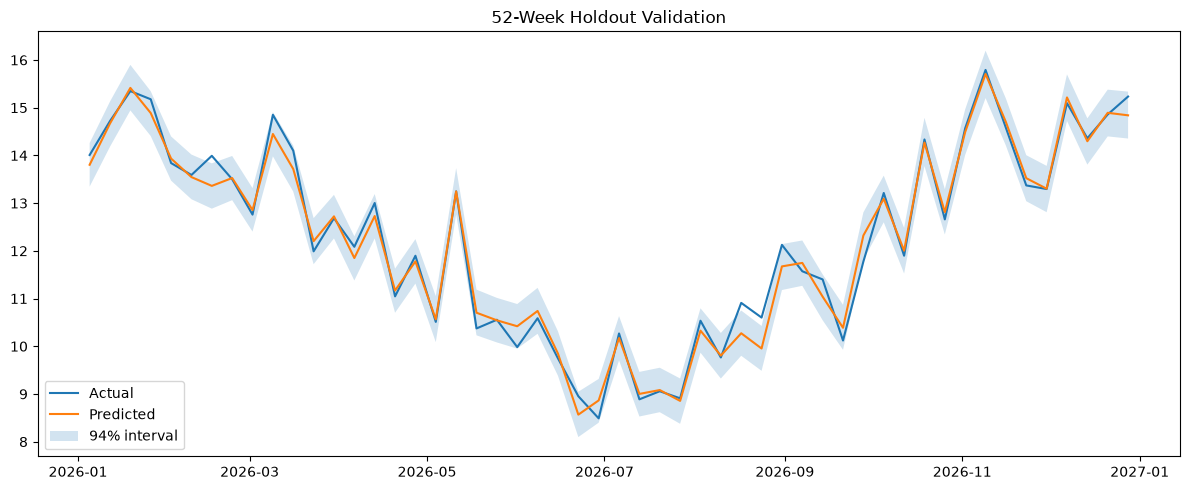

In [49]:
lower = y_pred.quantile(0.03, dim="sample").values
upper = y_pred.quantile(0.97, dim="sample").values

plt.figure(figsize=(12, 5))

plt.plot(test[DATE], y_test, label="Actual")
plt.plot(test[DATE], pred_mean, label="Predicted")
plt.fill_between(test[DATE], lower, upper, alpha=0.2, label="94% interval")

plt.title("52-Week Holdout Validation")
plt.legend()
plt.tight_layout()
plt.show()

,Spend Share,Contribution Share
Google Search,0.064,0.247
DV360,0.100,0.095
Facebook,0.060,0.217
AMS,0.050,0.204
TV,0.386,0.016
VOD,0.086,0.093
OOH,0.206,0.006
Radio,0.047,0.122


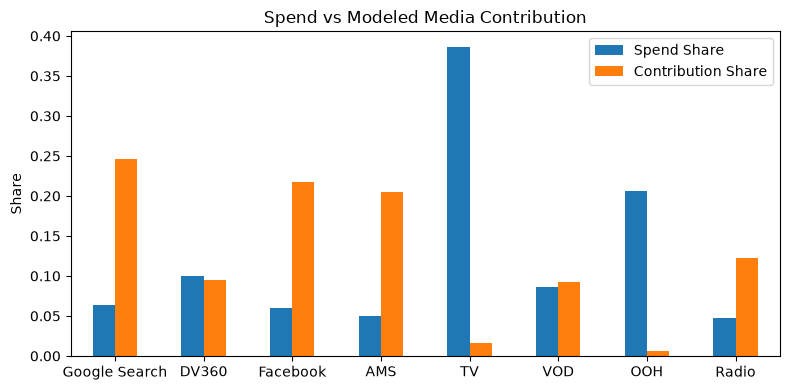

In [50]:
contrib = mmm.idata["posterior"]["channel_contribution_original_scale"]

total_contrib = (
    contrib
    .sum("date")
    .mean(("chain", "draw"))
    .to_series()
)

spend = train[CHANNELS].sum()

shares = pd.DataFrame({
    "Spend Share": spend / spend.sum(),
    "Contribution Share": total_contrib / total_contrib.sum(),
})

display(shares.round(3))

shares.plot(kind="bar", figsize=(8, 4))
plt.ylabel("Share")
plt.title("Spend vs Modeled Media Contribution")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [51]:
roas = mmm.incrementality.contribution_over_spend(
    frequency="all_time"
)

roas_dollar = (
    roas.median(dim=("chain", "draw"))
    * ROAS_SCALE
)

roas_summary = roas_dollar.to_series().sort_values(ascending=False)

display(
    roas_summary.to_frame("ROAS").round(2)
)

,ROAS
channel,
AMS,15.27
Google Search,14.49
Facebook,13.49
Radio,9.66
VOD,4.05
DV360,3.54
TV,0.14
OOH,0.09


In [52]:
mroas = mmm.incrementality.marginal_contribution_over_spend(
    frequency="all_time",
    spend_increase_pct=0.01,
)

mroas_dollar = (
    mroas.median(dim=("chain", "draw"))
    * ROAS_SCALE
)

mroas_summary = mroas_dollar.to_series().sort_values(ascending=False)

display(
    mroas_summary.to_frame("mROAS").round(2)
)

,mROAS
channel,
AMS,14.28
Google Search,13.80
Facebook,13.33
Radio,9.22
VOD,3.89
DV360,3.35
TV,0.12
OOH,0.08
